# Medieval Manuscript Pipeline — Stage-by-Stage Tests

Each section below is self-contained and tests exactly one pipeline stage.
Run sections in order on a first pass; afterwards you can re-run any section independently.

**Prerequisites:** activate your virtual environment and run `pip install -r requirements.txt` before starting the kernel.

In [2]:
%reload_ext autoreload
%autoreload 2

# ── Shared setup (run this first) ──────────────────────────────────────────
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import cv2

# Make sure the project root is importable
PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

EXEMPLARS_DIR = PROJECT_ROOT / "data" / "exemplars"
all_images = sorted(EXEMPLARS_DIR.glob("*.jpg"))
print(f"Found {len(all_images)} exemplar images.")

# Helper — pick images by substring
def pick(substring: str) -> Path:
    matches = [p for p in all_images if substring in p.name]
    if not matches:
        raise FileNotFoundError(f"No image matching '{substring}'")
    return matches[0]

def show(*imgs_titles, figsize=None):
    """Quick side-by-side display of grayscale or RGB arrays."""
    n = len(imgs_titles) // 2
    if figsize is None:
        figsize = (6 * n, 6)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, imgs_titles[::2], imgs_titles[1::2]):
        cmap = "gray" if img.ndim == 2 else None
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

print("Setup complete.")

Found 40 exemplar images.
Setup complete.


---
## Stage 1 — Binarisation (Sauvola)

In [ ]:
from pipeline.preprocessing import binarise

img_path = pick("double_simple")
bgr = cv2.imread(str(img_path))
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

# Default parameters
binary_default = binarise(gray, window_size=51, k=0.2)

# More aggressive (larger window, lower k → more ink retained)
binary_alt = binarise(gray, window_size=81, k=0.15)

show(
    gray, "Grayscale",
    binary_default, "Sauvola w=51 k=0.2",
    binary_alt, "Sauvola w=81 k=0.15",
    figsize=(18, 6),
)

---
## Stage 1b — Deskew

In [ ]:
from pipeline.preprocessing import deskew

# Artificially tilt the binary image to test the correction
from skimage.transform import rotate as sk_rotate

tilted = sk_rotate(binary_default, angle=2.5, resize=False,
                   mode="constant", cval=0, preserve_range=True).astype(np.uint8)

corrected, angle = deskew(tilted, angle_range=5.0, angle_step=0.5)
print(f"Detected deskew angle: {angle:.2f}°  (expected ≈ -2.5°)")

show(
    tilted, f"Tilted +2.5°",
    corrected, f"After deskew ({angle:.2f}°)",
    figsize=(12, 6),
)

---
## Stage 2 — Page extraction (crop + binding masking)

In [ ]:
info

In [ ]:
from pipeline.preprocessing import preprocess

# Test on several images with different binding sides
test_images = [
    pick("double_simple"),
    pick("single_simple"),
    pick("double_big_stain"),
    pick("single_top_double_bottom")
]

for img_path in test_images:
    result = preprocess(img_path)
    info = result["border_info"]
    print(
        f"{img_path.name[:50]:52s}  "
        f"binding={info['binding_side']:5s}  "
        f"margin_width={info['margin_width']:3d}px  "
        f"top_margin={info['top_margin']:3d}px  "
        f"bottom_margin={info['bottom_margin']:3d}px  "
        f"binding_width={info['binding_width']:3d}px  "
    )

In [ ]:
# Visual check of binding mask on one image
for img_path in test_images:
    result = preprocess(img_path)

    show(
        result["gray"],        "Grayscale",
        result["binary_desk"], "Binary + deskewed",
        result["masked"],      "Masked (binding + ruler removed)",
        figsize=(18, 7),
    )

---
## Stage 3 — Remove figures

In [ ]:
from pipeline.preprocessing import preprocess
from pipeline.masking import mask_non_text_kraken

prep = preprocess(pick("double_figures"))
result = mask_non_text_kraken(
    prep["bgr"],
    prep["masked"],
    model_path="/Users/luissalamanca/Library/Application Support/htrmopo/97665cf3-f83d-5594-8855-f28d3af9df7a/blla.mlmodel",
    device="mps",   # Apple Silicon GPU
    dilation_px=10, # wider margin around each text line
)

In [ ]:
result

---
## Stage 3 — Remove figures

In [ ]:
from pipeline.masking import mask_non_text_fullrgb

# Test on images known to have illustrations / stains
mask_tests = [
    pick("double_big_stain"),
    pick("double_figures"),
    pick("double_big_hole"),
]

for img_path in mask_tests:
    r = preprocess(img_path)
    m = mask_non_text_fullrgb(r["bgr"], r["binary"])
    n_ill = sum(1 for c in m.removed_components if c["type"] == "illustration")
    n_dmg = sum(1 for c in m.removed_components if c["type"] == "damage")
    print(
        f"{img_path.name[:50]:52s}  "
        f"illustrations={n_ill:2d}  damage={n_dmg:2d}  "
        f"text_coverage={m.text_coverage:.3f}"
    )

---
## Stage 3 — Layout detection

In [ ]:
from pipeline.layout import detect_layout

# Run on a variety of exemplars
layout_tests = [
    pick("double_simple"),
    pick("single_simple"),
    pick("single_top_double_bottom"),   # mixed layout
    pick("double_central_filigrane"),
]

for img_path in layout_tests:
    r = preprocess(img_path)
    layout = detect_layout(r["masked"])
    print(
        f"{img_path.name[:50]:52s}  "
        f"type={layout.layout_type:7s}  "
        f"cols={len(layout.columns)}  "
        f"transition={layout.transition_row}"
    )

In [ ]:
# Visualise column regions
COLOURS = ["red", "blue", "green", "orange"]

fig, axes = plt.subplots(1, len(layout_tests), figsize=(5 * len(layout_tests), 8))
for ax, img_path in zip(axes, layout_tests):
    r = preprocess(img_path)
    layout = detect_layout(r["masked"])
    ax.imshow(r["masked"], cmap="gray")
    for i, col in enumerate(layout.columns):
        rect = patches.Rectangle(
            (col.x_start, col.y_start), col.width, col.height,
            linewidth=2, edgecolor=COLOURS[i % 4], facecolor="none",
        )
        ax.add_patch(rect)
    if layout.transition_row:
        ax.axhline(layout.transition_row, color="yellow", lw=2, ls="--")
    ax.set_title(f"{layout.layout_type}\n{img_path.name.split('_')[1]}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Slab-vote heatmap — inspect per-slab column decisions
r = preprocess(pick("single_top_double_bottom"))
layout = detect_layout(r["masked"])

votes = np.array(layout.slab_votes).reshape(1, -1)
fig, (ax_img, ax_votes) = plt.subplots(1, 2, figsize=(12, 5),
                                        gridspec_kw={"width_ratios": [3, 1]})
ax_img.imshow(r["masked"], cmap="gray")
ax_img.set_title("Masked binary")
ax_img.axis("off")

im = ax_votes.imshow(votes.T, aspect="auto", cmap="bwr", vmin=1, vmax=2)
ax_votes.set_title("Slab votes\n(1=single, 2=double)")
ax_votes.set_xlabel("slab index")
ax_votes.set_yticks([])
plt.colorbar(im, ax=ax_votes, ticks=[1, 2])
plt.tight_layout()
plt.show()
print(f"Layout: {layout.layout_type}  |  Transition row: {layout.transition_row}")

---
## Stage 4 — Non-text masking

In [ ]:
from pipeline.masking import mask_non_text

# Test on images known to have illustrations / stains
mask_tests = [
    pick("double_big_stain"),
    pick("double_figures"),
    pick("double_big_hole"),
]

for img_path in mask_tests:
    r = preprocess(img_path)
    m = mask_non_text(r["masked"], r["gray"])
    n_ill = sum(1 for c in m.removed_components if c["type"] == "illustration")
    n_dmg = sum(1 for c in m.removed_components if c["type"] == "damage")
    print(
        f"{img_path.name[:50]:52s}  "
        f"illustrations={n_ill:2d}  damage={n_dmg:2d}  "
        f"text_coverage={m.text_coverage:.3f}"
    )

In [ ]:
# Visual overlay: red = illustration, yellow = damage
r = preprocess(pick("double_big_stain"))
m = mask_non_text(r["masked"], r["gray"])

overlay = cv2.cvtColor(r["masked"], cv2.COLOR_GRAY2BGR)
overlay[m.illustration_mask] = (0, 0, 200)
overlay[m.damage_mask]       = (0, 200, 200)

show(
    r["masked"],                            "Before masking",
    m.text_binary,                          "After masking",
    cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB), "Removed regions",
    figsize=(18, 7),
)

In [ ]:
# Check that small filigranes and initials are NOT removed
r = preprocess(pick("double_filigranes"))
m = mask_non_text(r["masked"], r["gray"])

print(f"Removed components: {len(m.removed_components)}")
for c in m.removed_components:
    print(f"  type={c['type']:12s}  area={c['area']:6d}  "
          f"bbox=({c['x']},{c['y']},{c['w']},{c['h']})")

show(
    r["masked"],   "Input",
    m.text_binary, "After masking (filigranes should survive)",
    figsize=(12, 7),
)

### Stage 4b — Kraken baseline segmentation masking

/Users/luissalamanca/Dropbox/My_stuff/05_SDSCresearch/10_SideProjects/00_MedievalCambridge/line_counting/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/luissalamanca/Dropbox/My_stuff/05_SDSCresearch/10_SideProjects/00_MedievalCambridge/line_counting/.venv/lib/python3.9/site-packages/coremltools/models/model.py:560: RuntimeWarning: You will not be able to run predict() on this Core ML model. Underlying exception message was: Error compiling model: "compiler error: Error reading protobuf spec. validator error: Input MLMultiArray to neural networks must have dimension 1 (vector) or 3 (image-like arrays).".
  _warnings.warn(



─────────────────────────────────────────────────────────────────
Image : MS-GG-00001-00001-000-00724_double_figures.jpg
  Image size          : 1170 × 2000  (2,340,000 px)
  Foreground (input)  : 200,699 px  (8.58%)
  Non-text mask       : 1,745,748 px  (74.60%)
  Text pixels kept    : 143,606 px  (6.14%)
  Text coverage       : 0.0614


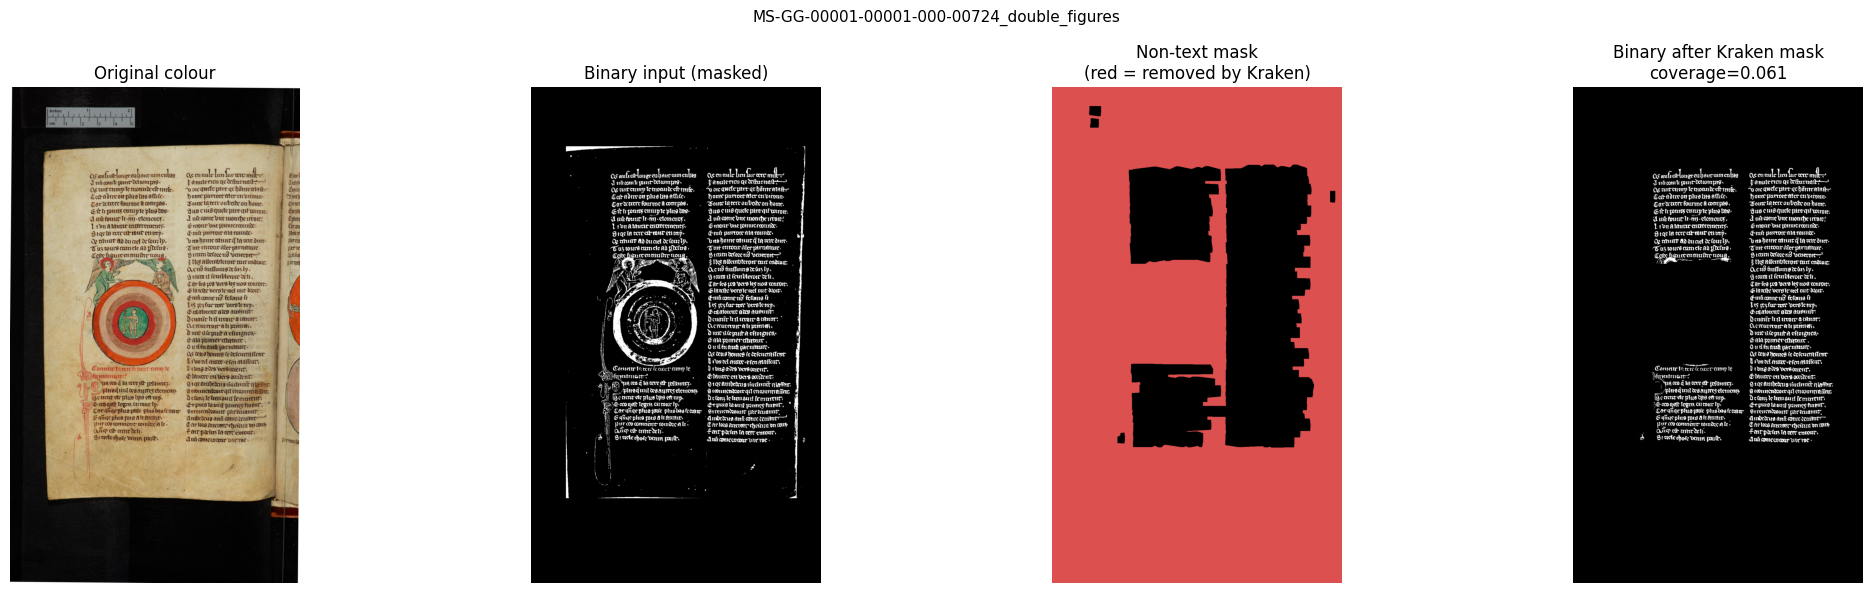

/Users/luissalamanca/Dropbox/My_stuff/05_SDSCresearch/10_SideProjects/00_MedievalCambridge/line_counting/.venv/lib/python3.9/site-packages/coremltools/models/model.py:560: RuntimeWarning: You will not be able to run predict() on this Core ML model. Underlying exception message was: Error compiling model: "compiler error: Error reading protobuf spec. validator error: Input MLMultiArray to neural networks must have dimension 1 (vector) or 3 (image-like arrays).".
  _warnings.warn(



─────────────────────────────────────────────────────────────────
Image : MS-GG-00001-00001-000-00284_double_big_stain.jpg
  Image size          : 1170 × 2000  (2,340,000 px)
  Foreground (input)  : 257,111 px  (10.99%)
  Non-text mask       : 1,678,010 px  (71.71%)
  Text pixels kept    : 186,891 px  (7.99%)
  Text coverage       : 0.0799


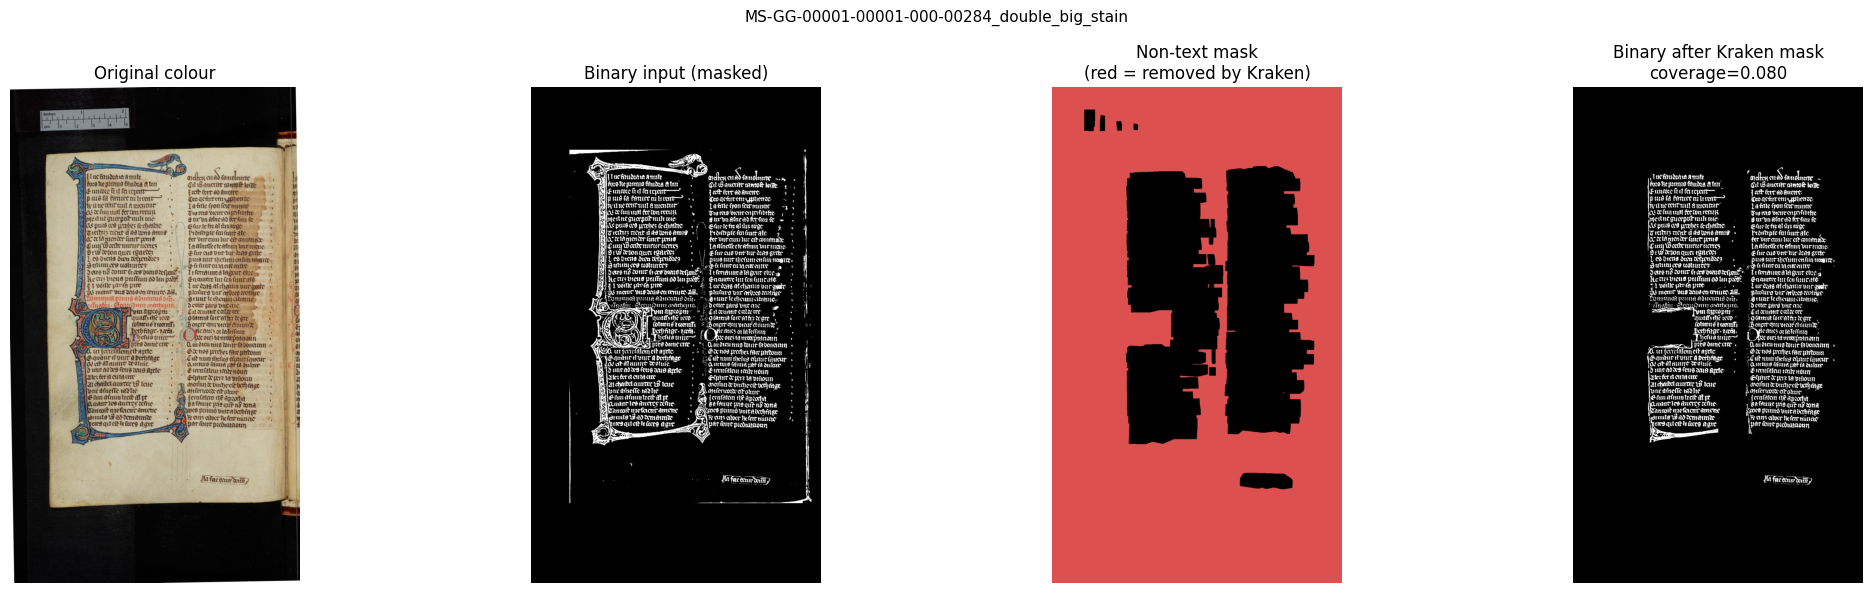

/Users/luissalamanca/Dropbox/My_stuff/05_SDSCresearch/10_SideProjects/00_MedievalCambridge/line_counting/.venv/lib/python3.9/site-packages/coremltools/models/model.py:560: RuntimeWarning: You will not be able to run predict() on this Core ML model. Underlying exception message was: Error compiling model: "compiler error: Error reading protobuf spec. validator error: Input MLMultiArray to neural networks must have dimension 1 (vector) or 3 (image-like arrays).".
  _warnings.warn(



─────────────────────────────────────────────────────────────────
Image : MS-GG-00001-00001-000-00822_single_inline_figure.jpg
  Image size          : 1170 × 2000  (2,340,000 px)
  Foreground (input)  : 256,331 px  (10.95%)
  Non-text mask       : 1,709,286 px  (73.05%)
  Text pixels kept    : 185,901 px  (7.94%)
  Text coverage       : 0.0794


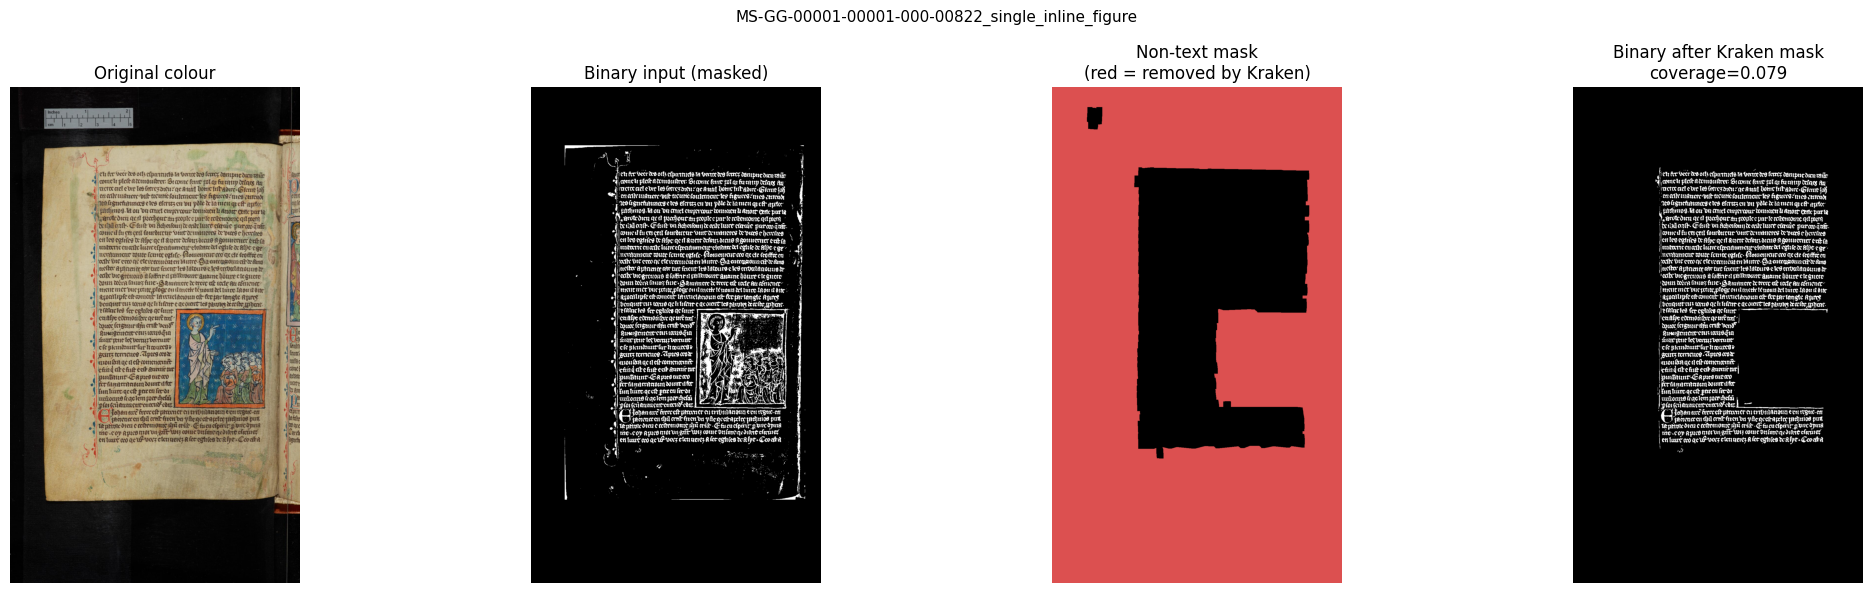

In [4]:
from pipeline.masking import mask_non_text_kraken
from pipeline.preprocessing import preprocess

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2

# Images with clear figures / illustrations to exercise the Kraken mask
kraken_tests = [
    pick("double_figures"),
    pick("double_big_stain"),
    pick("single_inline_figure"),
]

for img_path in kraken_tests:
    r = preprocess(img_path)
    result = mask_non_text_kraken(
        r["bgr"],
        r["masked"],
        model_path="/Users/luissalamanca/Library/Application Support/htrmopo/97665cf3-f83d-5594-8855-f28d3af9df7a/blla.mlmodel",
        device="mps",   # use "cpu" if MPS is unavailable
        dilation_px=10,
    )

    h, w = r["masked"].shape
    total_px = h * w
    non_text_px  = int(result.illustration_mask.sum())
    text_px      = int(result.text_binary.sum()) // 255
    input_fg_px  = int(r["masked"].sum()) // 255

    print(f"\n{'─'*65}")
    print(f"Image : {img_path.name}")
    print(f"  Image size          : {w} × {h}  ({total_px:,} px)")
    print(f"  Foreground (input)  : {input_fg_px:,} px  ({input_fg_px/total_px:.2%})")
    print(f"  Non-text mask       : {non_text_px:,} px  ({non_text_px/total_px:.2%})")
    print(f"  Text pixels kept    : {text_px:,} px  ({text_px/total_px:.2%})")
    print(f"  Text coverage       : {result.text_coverage:.4f}")

    # ── Visual panels ──────────────────────────────────────────────────────
    # Build a colour overlay: blue = non-text mask, green = text kept
    rgb = cv2.cvtColor(r["bgr"], cv2.COLOR_BGR2RGB)

    overlay = rgb.copy()
    overlay[result.illustration_mask]  = (200, 60,  60)   # red  = removed
    kept = (result.text_binary > 0) & ~result.illustration_mask
    # (kept is already what survived — show on a light bg)

    text_mask_vis = cv2.cvtColor(result.illustration_mask.astype("uint8") * 255,
                                  cv2.COLOR_GRAY2RGB)
    text_mask_vis[result.illustration_mask] = (220, 80, 80)   # red blobs

    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    fig.suptitle(img_path.stem, fontsize=11)

    axes[0].imshow(rgb)
    axes[0].set_title("Original colour")

    axes[1].imshow(r["masked"], cmap="gray")
    axes[1].set_title("Binary input (masked)")

    axes[2].imshow(text_mask_vis)
    axes[2].set_title("Non-text mask\n(red = removed by Kraken)")

    axes[3].imshow(result.text_binary, cmap="gray")
    axes[3].set_title(f"Binary after Kraken mask\ncoverage={result.text_coverage:.3f}")

    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


---
## Stage 5 — Line segmentation (HPP)

In [ ]:
from pipeline.segmentation import segment_lines

seg_tests = [
    pick("double_simple"),
    pick("single_simple"),
    pick("double_filigranes"),
    pick("single_initial_letter"),
]

for img_path in seg_tests:
    r = preprocess(img_path)
    layout = detect_layout(r["masked"])
    m = mask_non_text(r["masked"], r["gray"])
    seg = segment_lines(m.text_binary, layout.columns, method="hpp")
    print(
        f"{img_path.name[:50]:52s}  "
        f"lines={len(seg.lines):3d}  "
        f"per_col={seg.per_column_counts}  "
        f"median_h={seg.median_line_height:5.1f}px  "
        f"anomalous={seg.anomalous_count:2d}  "
        f"fallback={seg.fallback_triggered}"
    )

In [ ]:
# Visualise bounding boxes on one page
img_path = pick("double_simple")
r = preprocess(img_path)
layout = detect_layout(r["masked"])
m = mask_non_text(r["masked"], r["gray"])
seg = segment_lines(m.text_binary, layout.columns, method="hpp")

fig, ax = plt.subplots(figsize=(10, 14))
ax.imshow(m.text_binary, cmap="gray")
COL_COLOURS = ["red", "blue", "green", "orange"]
for line in seg.lines:
    x0, y0, x1, y1 = line.bbox
    c = "magenta" if line.is_anomalous else COL_COLOURS[line.column_index % 4]
    rect = patches.Rectangle((x0, y0), x1-x0, y1-y0,
                               linewidth=1, edgecolor=c, facecolor="none")
    ax.add_patch(rect)
    ax.text(x0+2, y0+10, str(line.line_index+1), fontsize=5, color=c)
ax.set_title(f"{img_path.name}\nLines: {len(seg.lines)}  Anomalous: {seg.anomalous_count}")
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Line height distribution
heights = [l.height for l in seg.lines]
median_h = seg.median_line_height

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(heights, bins=30, color="steelblue", edgecolor="white")
ax.axvline(median_h, color="red", lw=2, label=f"median = {median_h:.1f}px")
ax.axvline(2.5 * median_h, color="orange", lw=2, ls="--",
           label=f"2.5× median = {2.5*median_h:.1f}px (anomaly threshold)")
ax.set_xlabel("Line height (px)")
ax.set_ylabel("Count")
ax.set_title("Line height distribution")
ax.legend()
plt.tight_layout()
plt.show()

---
## Stage 5b — Anomaly detection & Kraken fallback logic

In [ ]:
# Force the HPP to see many anomalous lines by using a very tight threshold
from pipeline.segmentation import _flag_anomalies, _is_isolated_initial

r = preprocess(pick("single_initial_letter"))
layout = detect_layout(r["masked"])
m = mask_non_text(r["masked"], r["gray"])
seg = segment_lines(m.text_binary, layout.columns, method="hpp",
                    anomaly_height_factor=1.5)   # very sensitive

print(f"Lines: {len(seg.lines)}  Anomalous (factor=1.5): {seg.anomalous_count}")
for line in seg.lines:
    if line.is_anomalous:
        iso = _is_isolated_initial(line, seg.lines)
        print(f"  Line {line.line_index+1:3d} col={line.column_index}  "
              f"h={line.height:3d}px  isolated_initial={iso}")

---
## Stage 6 — Bounding boxes (tight fit + padding)

In [ ]:
# Compare bounding box tightness with different v_padding values
img_path = pick("double_simple")
r = preprocess(img_path)
layout = detect_layout(r["masked"])
m = mask_non_text(r["masked"], r["gray"])

seg_tight   = segment_lines(m.text_binary, layout.columns, v_padding=0)
seg_default = segment_lines(m.text_binary, layout.columns, v_padding=2)
seg_loose   = segment_lines(m.text_binary, layout.columns, v_padding=5)

# Show the first 3 lines of column 0 for each padding
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
binary = m.text_binary

for row_idx, (seg_var, label) in enumerate([
    (seg_tight, "v_padding=0"),
    (seg_default, "v_padding=2 (default)"),
    (seg_loose, "v_padding=5"),
]):
    col0_lines = [l for l in seg_var.lines if l.column_index == 0][:3]
    for col_idx, line in enumerate(col0_lines):
        x0, y0, x1, y1 = line.bbox
        crop = binary[max(0, y0-5):y1+5, max(0, x0-5):x1+5]
        axes[row_idx][col_idx].imshow(crop, cmap="gray")
        axes[row_idx][col_idx].set_title(
            f"{label}\nLine {line.line_index+1}, h={line.height}px", fontsize=7
        )
        axes[row_idx][col_idx].axis("off")

plt.tight_layout()
plt.show()

---
## Stage 7 — Structural feature vector

In [ ]:
from pipeline.embeddings import compute_structural_features

FEATURE_NAMES = [
    "layout=single", "layout=double", "layout=mixed",
    "total_lines_norm", "col_mean", "col_std",
    "med_height_norm", "std_height_norm",
    "n_large_comps", "area_frac", "text_coverage",
    "has_margin_text", "sep_width_norm",
]

struct_vecs = {}
for img_path in all_images[:6]:
    r = preprocess(img_path)
    layout = detect_layout(r["masked"])
    m = mask_non_text(r["masked"], r["gray"])
    seg = segment_lines(m.text_binary, layout.columns)
    vec = compute_structural_features(
        layout_type=layout.layout_type,
        per_column_counts=seg.per_column_counts,
        line_heights=[l.height for l in seg.lines],
        removed_components=m.removed_components,
        text_coverage=m.text_coverage,
        image_shape=r["gray"].shape,
        column_separator=layout.column_separator,
        columns=layout.columns,
        text_binary=m.text_binary,
    )
    struct_vecs[img_path.name] = vec
    print(f"{img_path.name[:45]:47s}  {np.array2string(vec, precision=3, suppress_small=True)}")

In [ ]:
# Heatmap of structural features
import pandas as pd

df_struct = pd.DataFrame(
    struct_vecs.values(),
    index=[k[:30] for k in struct_vecs],
    columns=FEATURE_NAMES,
)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(df_struct.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(df_struct)))
ax.set_yticklabels(df_struct.index, fontsize=7)
plt.colorbar(im, ax=ax)
ax.set_title("Structural feature vectors")
plt.tight_layout()
plt.show()

---
## Stage 7b — Visual embedding (ViT)

> **Note:** This cell downloads `vit_base_patch16_224` (~330 MB) on first run and uses MPS on Apple Silicon.

In [ ]:
from pipeline.embeddings import compute_visual_embedding, _get_device
import torch

print(f"Device: {_get_device()}")

r = preprocess(pick("double_simple"))
vit_vec = compute_visual_embedding(r["binary_desk"])
print(f"ViT embedding shape : {vit_vec.shape}")
print(f"Mean / std          : {vit_vec.mean():.4f} / {vit_vec.std():.4f}")
print(f"Min / max           : {vit_vec.min():.4f} / {vit_vec.max():.4f}")

In [ ]:
# Cosine similarity between a simple and a complex page
from sklearn.metrics.pairwise import cosine_similarity

r_simple  = preprocess(pick("double_simple"))
r_complex = preprocess(pick("double_many_figures"))

v_simple  = compute_visual_embedding(r_simple["binary_desk"])
v_complex = compute_visual_embedding(r_complex["binary_desk"])

sim = cosine_similarity(v_simple.reshape(1, -1), v_complex.reshape(1, -1))[0, 0]
print(f"Cosine similarity (simple vs complex): {sim:.4f}  (lower = more different)")

---
## Stage 7c — Anomaly scoring & UMAP

Process the first 10 exemplars and score them.

In [ ]:
from pipeline.embeddings import compute_embedding, anomaly_scores, compute_umap, PageEmbedding
from typing import List

embeddings: List[PageEmbedding] = []

for img_path in all_images[:10]:
    print(f"  {img_path.name[:50]:52s}", end="", flush=True)
    try:
        r = preprocess(img_path)
        layout = detect_layout(r["masked"])
        m = mask_non_text(r["masked"], r["gray"])
        seg = segment_lines(m.text_binary, layout.columns)
        emb = compute_embedding(
            filename=img_path.name,
            layout_type=layout.layout_type,
            per_column_counts=seg.per_column_counts,
            line_heights=[l.height for l in seg.lines],
            removed_components=m.removed_components,
            text_coverage=m.text_coverage,
            image_shape=r["gray"].shape,
            column_separator=layout.column_separator,
            columns=layout.columns,
            text_binary=m.text_binary,
            binary_for_vit=r["binary_desk"],
        )
        embeddings.append(emb)
        print(" ✓")
    except Exception as exc:
        print(f" ERROR: {exc}")

In [ ]:
# Score and rank
embeddings = anomaly_scores(embeddings)

print("Anomaly ranking (most anomalous first):")
for e in sorted(embeddings, key=lambda x: x.anomaly_score, reverse=True):
    bar = "█" * int(e.anomaly_score * 20)
    print(f"  {e.anomaly_score:.3f}  {bar:20s}  {e.filename}")

In [ ]:
# UMAP 2-D visualisation
if len(embeddings) >= 4:
    embeddings = compute_umap(embeddings)

    xs = [e.umap_xy[0] for e in embeddings]
    ys = [e.umap_xy[1] for e in embeddings]
    scores = [e.anomaly_score for e in embeddings]
    names = [e.filename for e in embeddings]

    fig, ax = plt.subplots(figsize=(9, 7))
    sc = ax.scatter(xs, ys, c=scores, cmap="RdYlGn_r", s=80, edgecolors="black", lw=0.5)
    for x, y, name in zip(xs, ys, names):
        ax.annotate(name.split("_")[4], (x, y), fontsize=6, ha="center", va="bottom")
    plt.colorbar(sc, ax=ax, label="Anomaly score")
    ax.set_title("UMAP of page embeddings (red = most anomalous)")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    plt.tight_layout()
    plt.show()
else:
    print("Need ≥ 4 embeddings for UMAP.")

---
## Full pipeline — batch test on all exemplars

In [ ]:
import pandas as pd

rows = []
for img_path in all_images:
    try:
        r       = preprocess(img_path)
        layout  = detect_layout(r["masked"])
        m       = mask_non_text(r["masked"], r["gray"])
        seg     = segment_lines(m.text_binary, layout.columns)
        rows.append({
            "filename"      : img_path.name,
            "layout_type"   : layout.layout_type,
            "n_columns"     : len(layout.columns),
            "total_lines"   : len(seg.lines),
            "per_column"    : str(seg.per_column_counts),
            "median_h_px"   : round(seg.median_line_height, 1),
            "anomalous"     : seg.anomalous_count,
            "fallback"      : seg.fallback_triggered,
            "text_coverage" : round(m.text_coverage, 3),
            "n_removed"     : len(m.removed_components),
            "deskew_angle"  : round(r["deskew_angle"], 2),
        })
    except Exception as exc:
        rows.append({"filename": img_path.name, "error": str(exc)})

df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 55)
pd.set_option("display.width", 160)
df

In [ ]:
# Summary statistics
numeric_cols = ["total_lines", "median_h_px", "anomalous", "text_coverage"]
df[numeric_cols].describe().round(2)

In [ ]:
# Distribution of total line counts
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["total_lines"].dropna(), bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Total lines per page")
axes[0].set_xlabel("Line count")

axes[1].hist(df["median_h_px"].dropna(), bins=20, color="darkorange", edgecolor="white")
axes[1].set_title("Median line height (px)")
axes[1].set_xlabel("Height (px)")

layout_counts = df["layout_type"].value_counts()
axes[2].bar(layout_counts.index, layout_counts.values, color=["steelblue","darkorange","green"])
axes[2].set_title("Layout type distribution")

plt.tight_layout()
plt.show()